In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fed_env import FedEnvBase, MockLLMObservationWrapper
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv

### How (The Implementation & Hyperparameters)
* **`MultiInputLstmPolicy`**: Stable-Baselines3's architecture that handles our `spaces.Dict`. It builds an LSTM network that processes the concatenated macro and LLM features over time.
* **`learning_rate = 0.0003`**: We reduced this back to the SB3 default (from 0.0005). LSTMs are highly susceptible to exploding gradients through time. A smaller learning rate ensures the memory gates update smoothly.
* **`n_steps = 512` & `batch_size = 128`**: LSTMs require truncated backpropagation through time. A smaller rollout buffer of 512 allows the LSTM to update its memory weights more frequently during the 1,000,000 timestep budget, accelerating sequence learning. The increased batch size of 128 ensures stable gradient updates.
* **`lstm_states` & `episode_starts`**: During evaluation, an LSTM needs to know what it was thinking one step ago. We manually capture its hidden memory state (`lstm_states`) and feed it back into the model. `episode_starts` tells the memory cell when to wipe its short-term memory (only on the very first step, `t=0`).

In [2]:
def train_and_evaluate_lstm():
    # Init POMDP Env for LSTM
    def make_env():
        return MockLLMObservationWrapper(FedEnvBase(llm_dim=5))

    # vectorize 4 environments for faster, more stable training
    env = DummyVecEnv([make_env for _ in range(4)])

    model = RecurrentPPO(
        "MultiInputLstmPolicy",
        env,
        learning_rate=0.0003,
        n_steps=512,
        batch_size=128,
        verbose=0,
        seed=42
    )

    model.learn(total_timesteps=1000000)

    # Eval
    eval_env = MockLLMObservationWrapper(FedEnvBase(llm_dim=5))
    obs, _ = eval_env.reset(seed=42)

    shock_start = eval_env.unwrapped.shock_start
    shock_end = eval_env.unwrapped.shock_end

    # memory trackers
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)

    history_lstm = {"pi": [], "u": [], "rate": [], "reward": []}
    total_reward = 0
    first_hike_time = None

    for t in range(60):
        action, lstm_states = model.predict(
            obs,
            state=lstm_states,
            episode_start=episode_starts,
            deterministic=True
        )
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        episode_starts = np.zeros((1,), dtype=bool)

        current_rate = obs["macro"][2]
        history_lstm["pi"].append(obs["macro"][0])
        history_lstm["u"].append(obs["macro"][1])
        history_lstm["rate"].append(current_rate)
        history_lstm["reward"].append(reward)
        total_reward += reward

        # regime detection latency dynamically calculated based on true shock_start
        if t >= shock_start and first_hike_time is None:
            if t > 0 and current_rate > history_lstm["rate"][t-1]:
                first_hike_time = t

    print("Eval metrics from proposal:")
    print(f"1. Quantitative Loss (Total Reward): {total_reward:.2f}")
    if first_hike_time:
        latency = first_hike_time - shock_start
        print(f"2. Regime Detection Latency: {latency} months")
    else:
        print("2. Regime Detection Latency: FAILED (Agent never hiked rates)")
    print("="*55 + "\n")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax1.plot(history_lstm["pi"], label="LSTM Inflation (%)", color="red", linewidth=2)
    ax1.plot(history_lstm["u"], label="LSTM Unemployment (%)", color="blue", linewidth=2)

    ax1.axvspan(shock_start, shock_end, color='gray', alpha=0.2, label="Latent Supply Shock")
    ax1.axhline(2.0, color='red', linestyle='--', alpha=0.3)
    ax1.axhline(4.0, color='blue', linestyle='--', alpha=0.3)
    ax1.set_title(f"RecurrentPPO (LSTM) | Total Reward: {total_reward:.2f}", fontweight='bold')
    ax1.set_ylabel("Rate (%)")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    ax2.step(range(len(history_lstm["rate"])), history_lstm["rate"], label="LSTM Policy Rate", color="darkorange", linewidth=2, where='post')
    ax2.axvspan(shock_start, shock_end, color='gray', alpha=0.2)

    if first_hike_time:
        ax2.axvline(first_hike_time, color='purple', linestyle=':', linewidth=2, label=f"Reaction Time: {latency}mo")

    ax2.set_xlabel("Timesteps (Months)")
    ax2.set_ylabel("Interest Rate (%)")
    ax2.legend(loc="upper left")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

Eval metrics from proposal:
1. Quantitative Loss (Total Reward): -175.30
2. Regime Detection Latency: 0 months



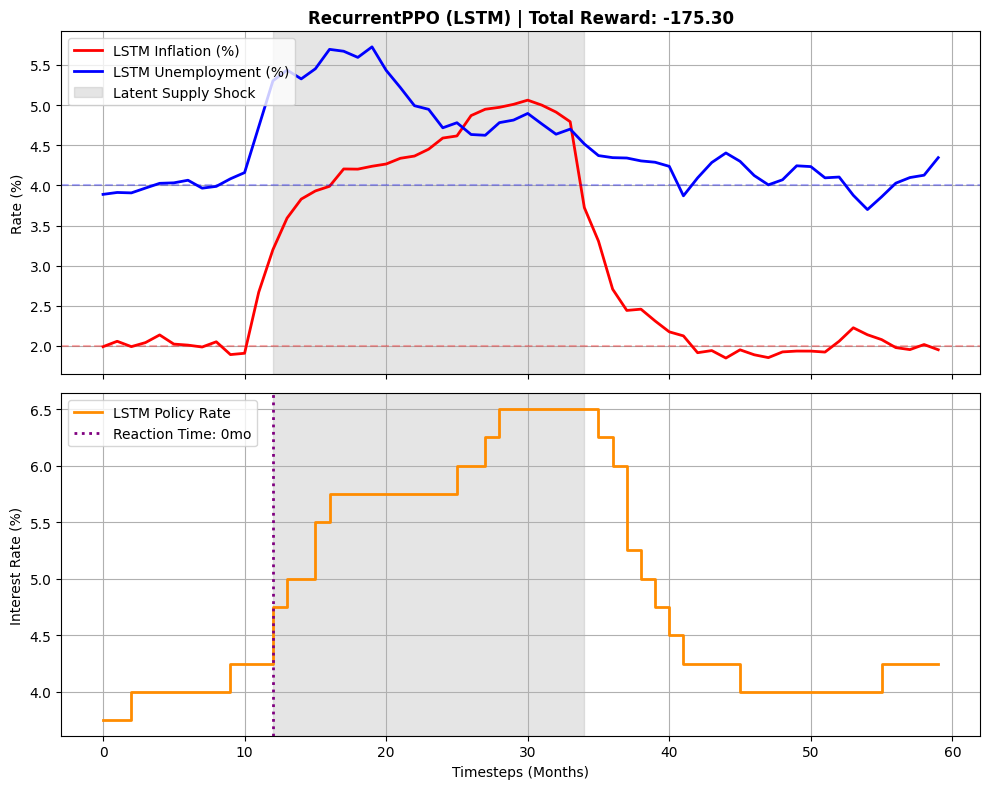

In [3]:
train_and_evaluate_lstm()